In [331]:
# load a matrix from a space-separated file and show it as an image
import sys
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/')
sys.path.append('/homes/ar2342/one_more_dir/contextual_frogs/')
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import os
from stat_utils import bic_gaussian_from_rmse
from model_utils import force_model_params, migrate_output_scale_to_input_scale_state_dict

def compute_k_params(model_state_dict, 
                     exclude_by_startwith=['_'], 
                     exclude_by_name=['sigma_x'], 
                     count_for_one={'sigma_b', 'direct_injection_scale','output_scale','u_feedback_scale', 
                                    'x_slow_alpha', 'x_fast_gain', 'x_fast_alpha'}):
    k_params = 0
    for key in model_state_dict:
        if any([key.startswith(excl) for excl in exclude_by_startwith]):
            continue
        if key in exclude_by_name:
            continue
        param_tensor = model_state_dict[key]
        this_param_size = param_tensor.shape[-1] if key not in count_for_one else 1
        print(f'param: {key}, size: {this_param_size}')
        k_params += this_param_size
    return k_params

def read_rmse_and_bic_from_path(bic_path,seeds):
    model_state_dict = torch.load(os.path.join(bic_path, 'model_state_dict.pt'), map_location='cpu')
    k_params = compute_k_params(model_state_dict)
    print(f'detected k_params: {k_params}')
    a_exp = np.loadtxt(os.path.join(bic_path, 'a_exp.txt'))
    a_pred = np.loadtxt(os.path.join(bic_path, 'a_pred.txt'))

    subjs = a_exp.shape[1] // seeds
    print(f'detected subjs: {subjs}')

    rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])
    n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
    assert np.all(n_samples == n_samples[:, [0]])
    n_samples = n_samples[:, 0]

    best_seed_idx = np.nanargmin(rmse, axis=1)
    best_rmse = rmse[np.arange(subjs), best_seed_idx]
    best_bics = [bic_gaussian_from_rmse(this_rmse, n=this_n, k=k_params) for this_rmse, this_n in zip(best_rmse, n_samples)]
    return {"best_rmse": np.array(best_rmse), "best_bics": np.array(best_bics)}

def myplot(data, color=None, style='-', label=None, align_by_endpoint=True, subj=[0,16], add_sem=True):
    if align_by_endpoint:
        x_data = np.arange(data.shape[0]) - (data.shape[0]-1)
    else:
        x_data = np.arange(data.shape[0])
    y_data = data[:, subj[0]:subj[1]]
    plt.plot(x_data, pooling_fun(y_data, axis=1), color=color, linestyle=style, label=label)
    if add_sem:
        n = np.sum(~np.isnan(y_data), axis=1)
        sem = np.divide(
            np.nanstd(y_data, axis=1, ddof=1),
            np.sqrt(n),
            out=np.zeros_like(x_data, dtype=float),
            where=n > 1,
        )
        plt.fill_between(
            x_data,
            pooling_fun(y_data, axis=1) - sem,
            pooling_fun(y_data, axis=1) + sem,
            color=color,
            alpha=0.2,
            linewidth=0,
        )


def eval_single_wrap(model, paradigm, args, paradigm_name=None, record_internals=False, record_vectors=False):
    outputs, internals = eval_single_paradigm(model, paradigm, args, paradigm_name, record_internals, record_vectors)
    outputs = [o.detach().cpu().numpy() for o in outputs]
    outputs = np.array(outputs)
    if record_internals:
        for k in internals:
            internals[k] = {kk: vv.detach().cpu().numpy() for kk, vv in internals[k].items()}
        return outputs, internals
    return outputs, None

# default seed count
seeds = 128//2 # 128*2#*2 # 18#72#18 #128
#



#!!!!
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/WZeroORDERxlpfSftPlusWdepLRscaleOutClmpLRRecvov40m_inj0p4_with_Nseeds_1'; at_y_eq_inf = "skip_plasticity"

#Averaged
# result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/froBmedian_MEANWZeroORDERxlpfSftPlusWdepLRscaleOutClmpLRRecvov40m_inj0p4_with_Nseeds_1'; at_y_eq_inf = 'skip_plasticity'


#Big REF1
result_path = '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_2ratesBound/'; seeds = 128*2;  at_y_eq_inf = "skip_slow_timescale_plasticity" 



In [332]:
rcConf = {
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
}
# ufigx,ufigy = (8.5 / 2, 4.2 / 1.5)
ufigx,ufigy = (7.5 / 2, 4.2 / 1.5)

In [333]:
#read saved model parameters
model_state_dict = torch.load(os.path.join(result_path, 'model_state_dict.pt'), map_location='cpu')
k_params = compute_k_params(model_state_dict)
print(f'detected k_params: {k_params}')

param: log_learning_rate, size: 2
param: sp_weight_decay, size: 2
detected k_params: 4


In [334]:


a_exp = np.loadtxt(os.path.join(result_path, 'a_exp.txt'))
a_pred = np.loadtxt(os.path.join(result_path, 'a_pred.txt'))


subjs = a_exp.shape[1] // seeds

In [335]:
rmse = np.sqrt(np.nanmean((a_exp - a_pred) ** 2,axis=0)).reshape([subjs, seeds])

rmse_ = np.sqrt(np.nanmean((a_exp - a_pred)[192:,:] ** 2,axis=0)).reshape([subjs, seeds]) 
n_samples = np.sum(~np.isnan(a_exp),axis=0).reshape([subjs, seeds])
#ensure n_samples is same in every row
assert np.all(n_samples == n_samples[:, [0]])
n_samples = n_samples[:, 0]

best_seed_idx = np.nanargmin(rmse, axis=1)
best_rmse = rmse[np.arange(subjs), best_seed_idx]


In [336]:
subjs

16

Text(0, 0.5, 'adaptation')

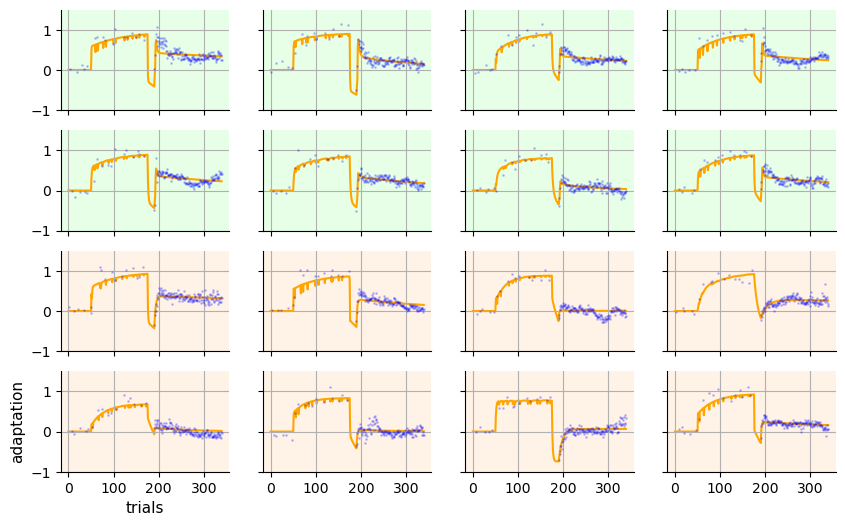

In [337]:


plt.figure(figsize=(10, 6))
plt.subplot(4, 4, 1)
cnt=0
for ii, (this_exp, this_pred) in enumerate(zip(a_exp.T, a_pred.T)):
    this_sub = ii//seeds
    plt.subplot(4, 4, 1 + this_sub)
    polarity = np.sign(np.nanmean(this_exp[:175]))
    if ii % seeds == 0:
        plt.plot(polarity*this_exp,'.', label='Experimental', color='blue', markersize=2, alpha=0.2)
    if ii % seeds == best_seed_idx[this_sub]:
        plt.plot(polarity*this_pred, label='Predicted', color='orange',zorder=0)
        plt.grid() #; print(cnt); cnt+=1
        plt.ylim([-1,1.5])

    if this_sub % 4 > 0:
        plt.gca().set_yticklabels([])
    if this_sub < 12:
        plt.gca().set_xticklabels([])

    if this_sub <8:
        # plt.axvspan(0, 340, color='green', alpha=0.01)
        plt.gca().set_facecolor((0.9,1,0.9))
    else:
        # plt.axvspan(0,340, color='orange', alpha=0.1)
        plt.gca().set_facecolor((1,0.95,0.9))

plt.subplot(4, 4, 13)
plt.xlabel('trials')
plt.ylabel('adaptation')
# plt.title('Experimental vs Predicted Data')
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/ersrFitsM19.pdf', format='pdf', bbox_inches='tight')# 
# plt.savefig('/homes/ar2342/one_more_dir/contextual_frogs/figs/lernerFitsM19.pdf', format='pdf', bbox_inches='tight')

In [338]:
these_bics = [bic_gaussian_from_rmse(this_rmse, n=this_n, k=k_params) for this_rmse, this_n in zip(best_rmse, n_samples)]

In [339]:
coin_bics_path = '/homes/ar2342/one_more_dir/contextual_frogs/experimental/optim/coin_bics1000.txt'
coin_bics = np.loadtxt(coin_bics_path)

In [340]:
n_samples

array([165, 165, 165, 165, 165, 165, 165, 165, 167, 167, 167, 167, 167,
       167, 167, 167])

<StemContainer object of 3 artists>

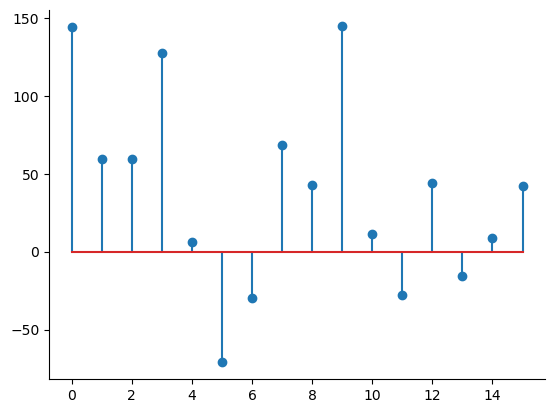

In [341]:
plt.stem(these_bics-coin_bics)

In [342]:
best_seed_idx_within_batch = best_seed_idx +(np.arange(subjs) * seeds)

#create a new model state dict with only the best seeds (seeds are the leading dimension of each parameter tensor)
best_model_state_dict = {}
for key, value in model_state_dict.items():
        print(key, value.shape)
        best_model_state_dict[key] = value[best_seed_idx_within_batch] if not key.startswith('_') else value


log_learning_rate torch.Size([4096, 2])
sp_weight_decay torch.Size([4096, 2])
sigma_x torch.Size([4096])
_z_biases torch.Size([1])
_w_in torch.Size([1])
_w_inq torch.Size([1])


In [343]:
from models_part2 import BatchedElboGenerativeModelTopMulti
import yaml
from types import SimpleNamespace
args_path = os.path.join(result_path, 'args.yaml')
with open(args_path, 'r') as f:
    args_dict = yaml.unsafe_load(f) #safe_load(f)
args = SimpleNamespace(**args_dict)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [344]:
import pickle

In [345]:
args.bs = subjs  #set batch size to number of subjects

In [346]:
if args.enable_output_scale_tuning:
    if hasattr(args, 'enable_input_scale_tuning') and args.enable_input_scale_tuning:
        raise ValueError('Both output scale tuning and input scale tuning cannot be enabled at the same time, for now.')
    if args.nl_activation != 'relu':
        raise ValueError('Scaling migration is currently only implemented for ReLU nonlinearity'
        '.')
    args.enable_output_scale_tuning = False
    args.enable_input_scale_tuning = True
    # args.softclamp_input_scale_0to1 = args.softclamp_output_scale_0to1 if hasattr(args, 'softclamp_output_scale_0to1') else False

    best_model_state_dict = migrate_output_scale_to_input_scale_state_dict(best_model_state_dict, 
                                                                           remove_output_scale=True,
                                                                           apply_softclamp_output_scale_0to1=args.softclamp_output_scale_0to1 if hasattr(args, 'softclamp_output_scale_0to1') else False,
                                                                           model_for_softclamp=BatchedElboGenerativeModelTopMulti(device=device, args=args) ) 
    print('Migrated output scale parameters to input scale parameters in the model state dict, and disabled output scale tuning while enabling input scale tuning.')
    args.softclamp_output_scale_0to1 = False

# args.fixed_injection_param = 0.4




In [347]:
best_model_state_dict.keys()


dict_keys(['log_learning_rate', 'sp_weight_decay', 'sigma_x', '_z_biases', '_w_in', '_w_inq'])

In [348]:
args.at_y_eq_inf = at_y_eq_inf
if at_y_eq_inf=="skip_slow_timescale_plasticity":
    #ensure that in best_model_state_dict learning rates are sorted from low to high (and weight decays accordingly)
    #'log_learning_rate', 'sp_weight_decay' are the effected parameters
    # lr_order = np.argsort(best_model_state_dict['log_learning_rate'])
    # sorted_lr = best_model_state_dict['log_learning_rate'][:,lr_order]
    # sorted_weight_decay = best_model_state_dict['sp_weight_decay'][:,lr_order]

    sorted_lr, lr_order = torch.sort(best_model_state_dict['log_learning_rate'], dim=1, descending=False)
    sorted_weight_decay = torch.gather(best_model_state_dict['sp_weight_decay'], dim=1, index=lr_order)
    best_model_state_dict['log_learning_rate'] = sorted_lr
    best_model_state_dict['sp_weight_decay'] = sorted_weight_decay

In [349]:
#load the best model state dict
best_model_dir = os.path.join(result_path, 'best_model_state_dict')
model_state_dict_save_path = os.path.join(best_model_dir, 'model_state_dict.pt')
best_model_state_dict = torch.load(model_state_dict_save_path, map_location=torch.device('cpu'))

args_save_path = os.path.join(best_model_dir, 'args.yaml')
with open(args_save_path) as f:
    args = yaml.load(f, Loader=yaml.FullLoader)
args = SimpleNamespace(**args)


FileNotFoundError: [Errno 2] No such file or directory: '/homes/ar2342/one_more_dir/contextual_frogs/results_part2/state_space_2ratesBound/best_model_state_dict/model_state_dict.pt'

In [350]:
model = BatchedElboGenerativeModelTopMulti(device=device, args=args, 
                                           **(dict(fudge=args.fudge) if hasattr(args, 'fudge') else {}  )).to(device)
model.get_biases_and_w_in(args.n, device=device)
model.load_state_dict(best_model_state_dict)

<All keys matched successfully>

In [351]:
# best_model_state_dict = migrate_output_scale_to_input_scale_state_dict(best_model_state_dict, remove_output_scale=True)


In [352]:
def eval_single_paradigm(model, 
                         paradigm, 
                         args, 
                         paradigm_name=None, 
                         record_internals=False, 
                         record_vectors=False,
                         noise_spikes=[]):
    if paradigm_name is not None:
        print(f"evaluating paradigm {paradigm_name} with {len(paradigm)} steps")
    ys = torch.tensor(paradigm, device=next(model.parameters()).device)
    # duplicate ys across batch size
    ys = ys.unsqueeze(0).repeat(args.bs, 1)  # [bs, t]
    # noises = torch.randn((args.bs, ys.shape[1]), device=next(model.parameters()).device) * model.sigma_x  # [bs, t]
    noises = torch.zeros((args.bs, ys.shape[1]), device=next(model.parameters()).device)  # [bs, t]
    for t in noise_spikes:
        if t < noises.shape[1]:
            noises[:, t] = 1

    noises = [noises[:, t_idx] for t_idx in range(noises.shape[1])]
    ys = [ys[:, t_idx] for t_idx in range(ys.shape[1])]
    if paradigm_name is not None:
        print(f"noises shape: {noises[0].shape}, ys shape: {ys[0].shape}")
    model_setting = args.model
    outputs_ = model.f(
        args.n,
        noises,
        ys,
        model_setting,
        qs=None,
        record_internals=record_internals,
        record_vectors=record_vectors,
    )
    if record_internals:
        outputs_, internals = outputs_
        return outputs_, internals
    return outputs_, None


def local_eval_paradigms(model, playlist_file, args, record_internals=False, record_vectors=False):
    with open(playlist_file, "rb") as f:
        playlist = pickle.load(f)

    model.eval()
    with torch.no_grad():
        outputs = {}
        internals_by_paradigm = {} if record_internals else None
        for paradigm_name, paradigm in playlist.items():
            outputs_, internals = eval_single_paradigm(
                model,
                paradigm,
                args,
                paradigm_name=paradigm_name,
                record_internals=record_internals,
                record_vectors=record_vectors,
            )
            outputs[paradigm_name] = np.array([z.cpu().numpy().reshape(-1) for z in outputs_])
            if record_internals:
                internals_by_paradigm[paradigm_name] = internals
    if record_internals:
        return outputs, internals_by_paradigm
    return outputs

In [353]:
# paradigm_file='/homes/ar2342/one_more_dir/contextual_frogs/signoffrepertoire4.3h100.pkl'
paradigm_file='/homes/ar2342/one_more_dir/contextual_frogs/signoffrepertoire4.3.pkl'

with open(paradigm_file, "rb") as f:
        playlist = pickle.load(f)

In [354]:

# force_model_params(model, forced_params)

ooo, internals = local_eval_paradigms(model, paradigm_file, args, record_internals=True,)

evaluating paradigm savings with 440 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB0 with 280 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB1 with 293 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB2 with 321 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB3 with 392 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB4 with 510 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm AB5 with 690 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm spontaneous with 340 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm evoked with 340 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm visw1p2 with 1150 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


In [355]:

pooling_fun = np.mean

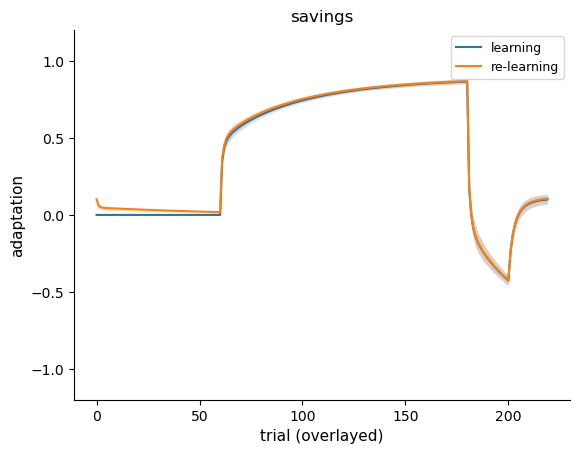

In [356]:
learning = ooo['savings'][:220]
relearning = ooo['savings'][220:]

learning_mean = pooling_fun(learning, axis=1)
relearning_mean = pooling_fun(relearning, axis=1)

learning_n = np.sum(~np.isnan(learning), axis=1)
relearning_n = np.sum(~np.isnan(relearning), axis=1)
learning_sem = np.divide(
    np.nanstd(learning, axis=1, ddof=1),
    np.sqrt(learning_n),
    out=np.zeros_like(learning_mean, dtype=float),
    where=learning_n > 1,
)
relearning_sem = np.divide(
    np.nanstd(relearning, axis=1, ddof=1),
    np.sqrt(relearning_n),
    out=np.zeros_like(relearning_mean, dtype=float),
    where=relearning_n > 1,
)

x_learning = np.arange(learning_mean.shape[0])
x_relearning = np.arange(relearning_mean.shape[0])

plt.plot(learning_mean, label='learning', color='tab:blue')
plt.fill_between(
    x_learning,
    learning_mean - learning_sem,
    learning_mean + learning_sem,
    color='tab:blue',
    alpha=0.2,
    linewidth=0,
)

plt.plot(relearning_mean, label='re-learning', color='tab:orange')
plt.fill_between(
    x_relearning,
    relearning_mean - relearning_sem,
    relearning_mean + relearning_sem,
    color='tab:orange',
    alpha=0.2,
    linewidth=0,
)

plt.title('savings')
plt.xlabel('trial (overlayed)')
plt.ylabel('adaptation')
plt.ylim([-1.2, 1.2])
plt.legend()

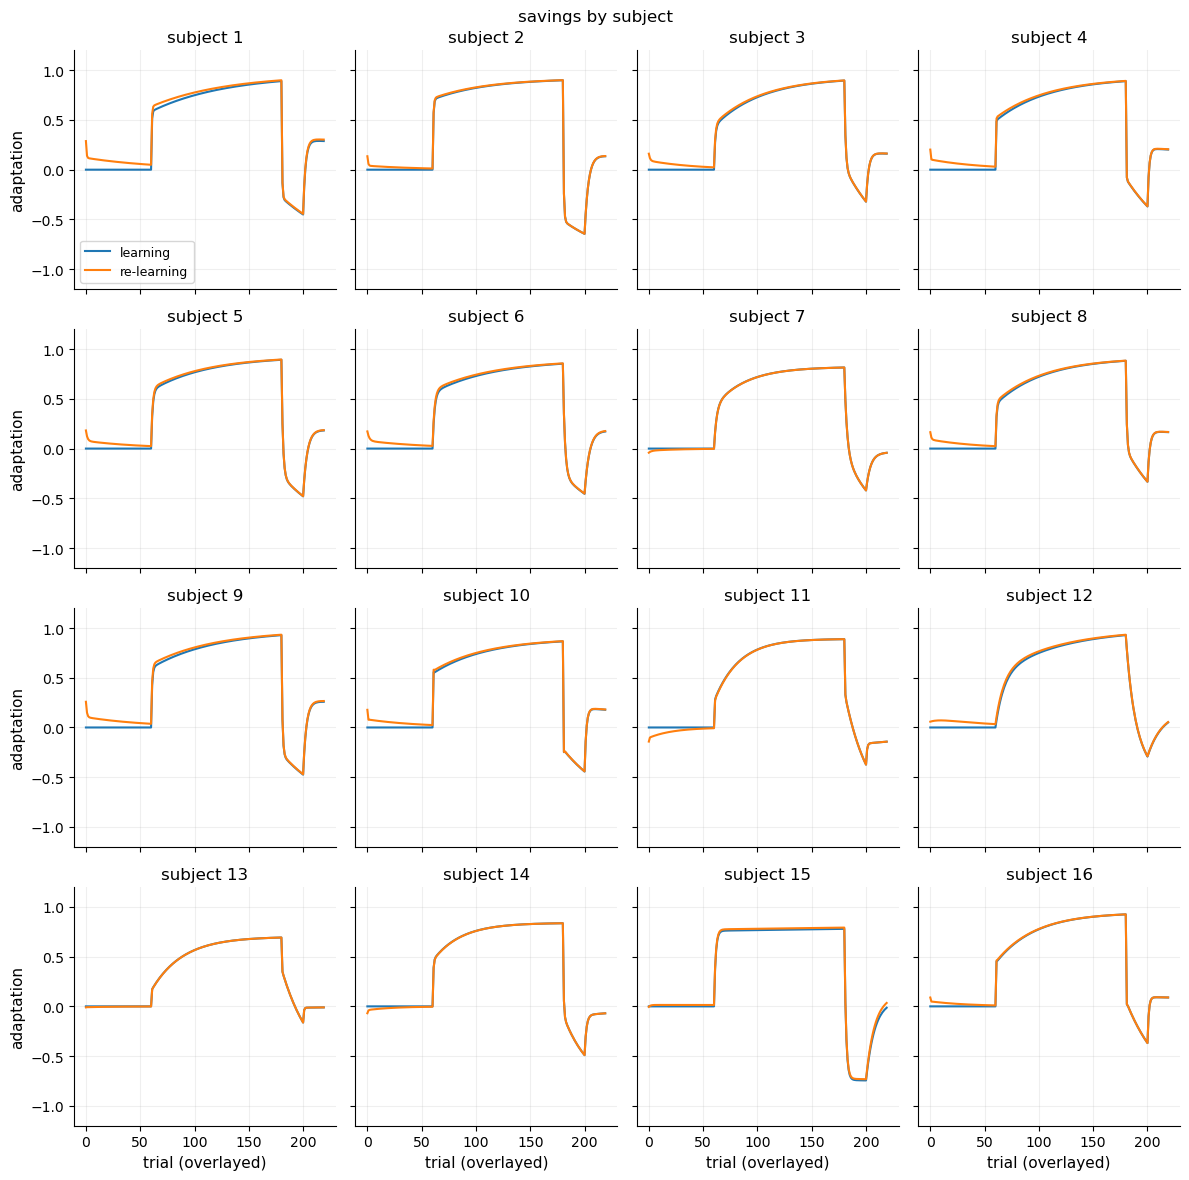

In [357]:
savings = ooo['savings']
split_idx = savings.shape[0] // 2

fig, axes = plt.subplots(4, 4, figsize=(12, 12), sharex=True, sharey=True)
for subj, ax in enumerate(axes.flat):
    ax.plot(savings[:split_idx, subj], label='learning')
    ax.plot(savings[split_idx:, subj], label='re-learning')
    ax.set_title(f'subject {subj + 1}')
    ax.set_ylim([-1.2, 1.2])
    ax.grid(alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel('trial (overlayed)')

for ax in axes[:, 0]:
    ax.set_ylabel('adaptation')

axes[0, 0].legend()
fig.suptitle('savings by subject')
fig.tight_layout()

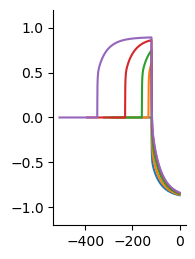

In [358]:
ant_list = [f'AB{i}' for i in range(0,5)]

plt.figure(figsize=(ufigx, ufigy))
for ii, smooth_fun in enumerate([lambda x: x]): #,lambda x: smooth_signal(x, 2)]):
    plt.subplot(1,2,ii+1)
    # plt.title('anterograde interference')
    for ant in ant_list:
        x_data = np.arange(len(ooo[ant].mean(axis=1)))
        plt.plot(x_data-np.max(x_data),smooth_fun(pooling_fun(ooo[ant], axis=1)))
    plt.ylim([-1.2, 1.2])

Text(0.5, 1.0, 'environmental consistency')

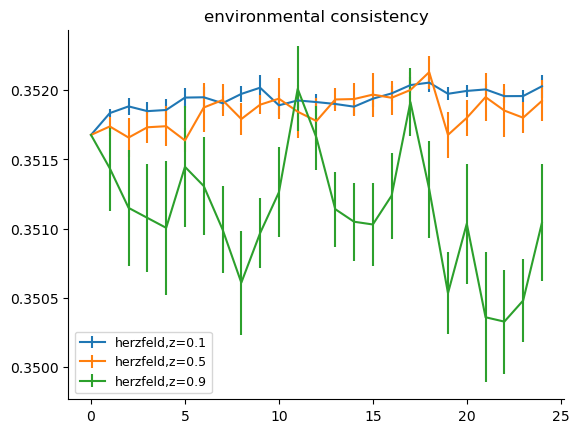

In [359]:
deltas_by_super_scenario = {}
for i, this_data in enumerate([ooo]):

    for iz, z in enumerate(ooo.keys()):
        if 'herzfeld' not in z:
            continue
        else:
            scenario = z
            super_scenario = z.split('$')[0]
        deltas = []
        mm = lambda x: np.mean(x,axis=0)
        this_result = pooling_fun(this_data[scenario],axis=1)
        pointer = 0
        for bb in range(25):
            block_length = len(this_result)//25
            deltas.append(this_result[pointer+2]-this_result[pointer])
            pointer += block_length

        if super_scenario not in deltas_by_super_scenario:
            deltas_by_super_scenario[super_scenario] = []
        deltas_by_super_scenario[super_scenario].append(deltas)

plt.figure()
for k in deltas_by_super_scenario:

    data = np.array(deltas_by_super_scenario[k])
    mean = np.mean(data,axis=0)
    std = np.std(data,axis=0)
    plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)

plt.legend()
plt.title('environmental consistency')
# plt.ylim(-1,1.2)

Text(0, 0.5, 'single trial learning')

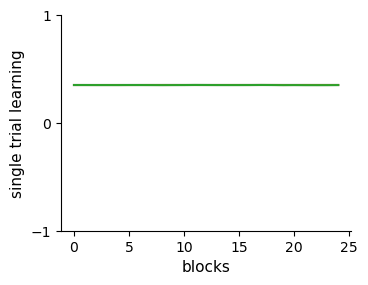

In [360]:
plt.rcParams.update(rcConf)

fig1, ax_traj = plt.subplots(figsize=(ufigx, ufigy))

# myplot(savings[:220],align_by_endpoint=False)
# myplot(savings[220:],align_by_endpoint=False)

for k in deltas_by_super_scenario:

    data = np.array(deltas_by_super_scenario[k])
    myplot(data.T, label=k,align_by_endpoint=False)
# ax_traj.set_xticklabels([ '$P^+$\n onset', '$P^-$\n onset', '$P^c$\n onset'])
# ax_traj.set_xticklabels([ '$P^+$', '$P^-$', '$P^c$'])
ax_traj.set_xlabel('blocks')


ax_traj.set_yticks([-1, 0, 1])
ax_traj.set_ylabel('single trial learning')
# fig1.savefig('part2_herzf_adapt.svg', format='svg', bbox_inches='tight')
# fig1.savefig('part2_herzf_linear.svg', format='svg', bbox_inches='tight')

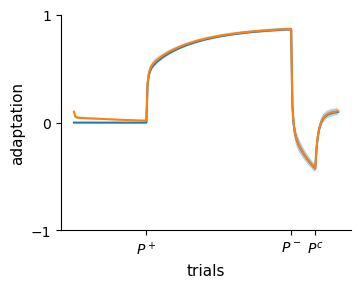

In [361]:
requested_timepoints = [60, 180, 200]

plt.rcParams.update(rcConf)

fig1, ax_traj = plt.subplots(figsize=(ufigx, ufigy))

myplot(savings[:220],align_by_endpoint=False)
myplot(savings[220:],align_by_endpoint=False)

ax_traj.set_xticks(requested_timepoints[:3])
# ax_traj.set_xticklabels([ '$P^+$\n onset', '$P^-$\n onset', '$P^c$\n onset'])
ax_traj.set_xticklabels([ '$P^+$', '$P^-$', '$P^c$'])
ax_traj.set_xlabel('trials')


ax_traj.set_yticks([-1, 0, 1])
ax_traj.set_ylabel('adaptation')
fig1.savefig('part2_savings_linear.svg', format='svg', bbox_inches='tight')
# ax_traj.set_yticklabels([ '$P^+$', '$P^0$', '$P^+$'])

(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)
(1125, 16)

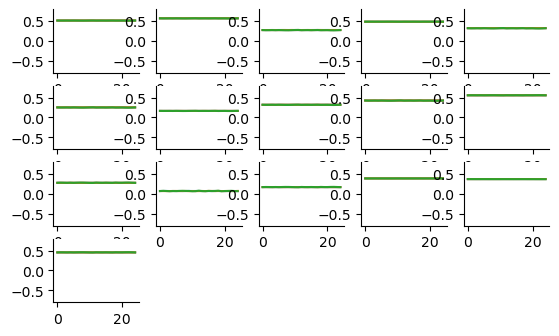

In [362]:
for pp in range(subjs):
    plt.subplot(5,5,pp+1)
    deltas_by_super_scenario = {}

    for i, this_data in enumerate([ooo]):
        # print(i)
        for iz, z in enumerate(ooo.keys()):
            if 'herzfeld' not in z:
                continue
            else:
                scenario = z
                super_scenario = z.split('$')[0]
            deltas = []
            mm = lambda x: np.mean(x,axis=0)
            # scenario = f'herzfeld,z={z}'
            # this_result = this_data[scenario].mean(axis=1)
            # print(f'processing subject {pp}, scenario {scenario}, result shape {this_data[scenario].shape}')
            # this_result = pooling_fun(this_data[scenario],axis=1)
            print(this_data[scenario].shape)
            this_result = this_data[scenario][:,pp]
            pointer = 0
            for bb in range(25):
                block_length = len(this_result)//25
                # print(this_result.shape)
                deltas.append(this_result[pointer+2]-this_result[pointer])
                pointer += block_length

            if super_scenario not in deltas_by_super_scenario:
                deltas_by_super_scenario[super_scenario] = []
            deltas_by_super_scenario[super_scenario].append(deltas)

        for k in deltas_by_super_scenario:
            # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
            #present with error bars
            data = np.array(deltas_by_super_scenario[k])
            mean = np.mean(data,axis=0)
            # std = np.std(data,axis=0)
            # plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
            plt.plot(np.arange(len(mean)),mean,label=k)

        # plt.legend()
        # plt.title('environmental consistency')
        plt.ylim(-0.8,0.8)

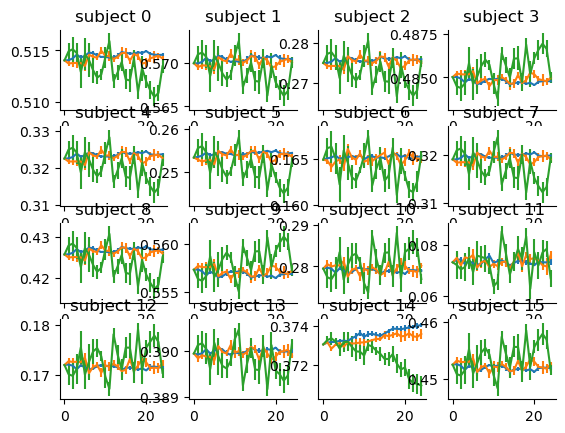

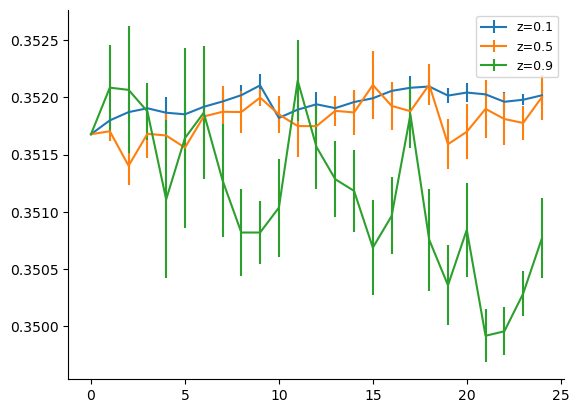

In [363]:
dd = {}
herz_z = [0.1,0.5,0.9]
for this_herz_z in herz_z:
    dd[this_herz_z] = []

    for ii in range(5):
        x_traj = internals[f'herzfeld,z={this_herz_z}${ii}']['x'].cpu().numpy()
        u_traj = internals[f'herzfeld,z={this_herz_z}${ii}']['u'].cpu().numpy()
        e_traj = internals[f'herzfeld,z={this_herz_z}${ii}']['e'].cpu().numpy()
        t1 = np.arange(0,25*45,45)
        t2 = t1+2
        dd[this_herz_z].append(u_traj[t2,:] - u_traj[t1,:])

plt.figure()
for this_herz_z in herz_z:
    for ss in range(dd[this_herz_z][0].shape[1]):
        plt.subplot(4,4,ss+1)
        data = np.array(dd[this_herz_z])[:,:,ss]
        mean = np.mean(data,axis=0)
        std = np.std(data,axis=0)
        plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]), label=f'z={this_herz_z}')
        plt.title(f'subject {ss}')
        # plt.ylim(-0.8,0.8)
plt.figure()
for this_herz_z in herz_z:
    data = np.mean(dd[this_herz_z],axis=-1)
    mean = np.mean(data,axis=0)
    std = np.std(data,axis=0)
    plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]), label=f'z={this_herz_z}')
plt.legend()
# plt.ylim(-0.8,0.8)  

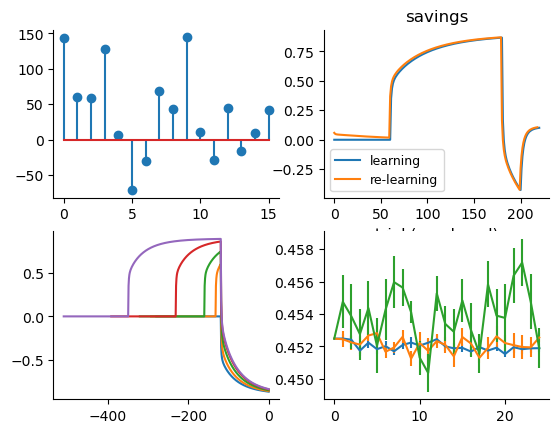

In [364]:
plt.subplot(2,2,1)
plt.stem(these_bics-coin_bics)
plt.subplot(2,2,2)
plt.plot(pooling_fun(ooo['savings'][:221], axis=1) , label='learning')
plt.plot(pooling_fun(ooo['savings'][221:], axis=1), label='re-learning')
# for subj in range(subjs):
    # plt.plot(ooo['savings'][221:, subj], color='gray', alpha=0.3)
plt.title('savings')
plt.xlabel('trial (overlayed)')
# plt.ylabel('adaptation')
plt.legend()
plt.subplot(2,2,3)
# plt.title('anterograde interference')
for ant in ant_list:
    x_data = np.arange(len(ooo[ant].mean(axis=1)))
    plt.plot(x_data-np.max(x_data),pooling_fun(ooo[ant], axis=1))
    # for subj in range(subjs):
    #     plt.plot(x_data-np.max(x_data),ooo[ant][:, subj], color='gray', alpha=0.3)
plt.subplot(2,2,4)
for k in deltas_by_super_scenario:
    # plt.plot(np.mean(deltas_by_super_scenario[k],axis=0),label=k)
    #present with error bars
    data = np.array(deltas_by_super_scenario[k])
    mean = pooling_fun(data,axis=0)
    std = np.std(data,axis=0)
    plt.errorbar(np.arange(len(mean)),mean,yerr=std/np.sqrt(data.shape[0]),label=k)
    # plt.plot(np.arange(len(mean)),mean,label=k)


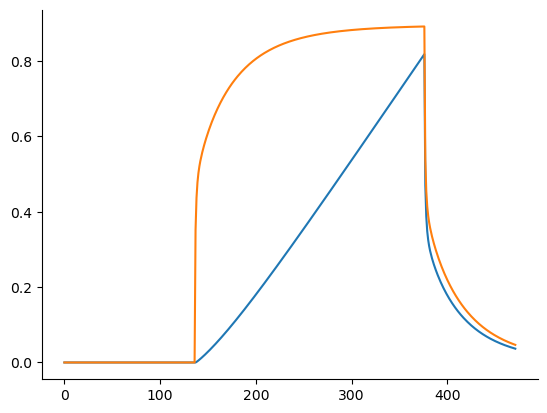

In [365]:
plt.plot(ooo['frogs'].mean(axis=1), label='frogs')
plt.plot(ooo['anti_frogs'].mean(axis=1), label='frogs')

In [366]:
huberdeau5min_paradigm = np.array([0]*20+[1]*5+[np.nan]*15+[1]*50)
huberdeau0_paradigm = np.array([0]*20+[1]*50)

huberdeau5min_out = eval_single_wrap(model, huberdeau5min_paradigm, args, paradigm_name='huberdeau5min', record_internals=False, record_vectors=False)[0]
huberdeau0_out = eval_single_wrap(model, huberdeau0_paradigm, args, paradigm_name='huberdeau0', record_internals=False, record_vectors=False)[0]


evaluating paradigm huberdeau5min with 90 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huberdeau0 with 70 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


(-50.0, -20.0)

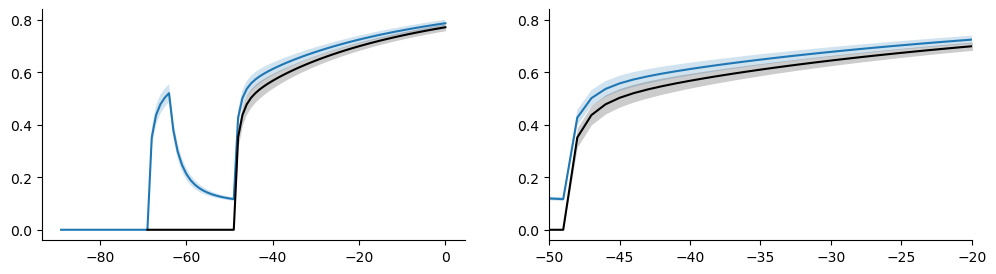

In [367]:
plt.figure(figsize=(12,3)
           )
plt.subplot(1,2,1)
myplot(huberdeau5min_out)
myplot(huberdeau0_out,'k')
plt.subplot(1,2,2)
myplot(huberdeau5min_out)
myplot(huberdeau0_out,'k')
plt.xlim(-50, -20)

In [368]:
# huberdeau5min_paradigm = np.array([0]*20+[1]*5+[np.nan]*15+[1]*50)
huberdeau5min_paradigm = np.array([0]*20+[1]*5+[np.inf]*15+[1]*30)
huberdeau5min_ctrl = np.array([0]*20+[1]*5+[np.nan]*15+[1]*30)
huberdeau0_paradigm = np.array([0]*20+[1]*30)

wait_time_equiv = 30*4
rot_num = [0,2,5,10,40]
huberdeau_rot_paradigms = {rot:np.array([0]*20+[1]*rot+[np.nan]*wait_time_equiv+[1]*30) for rot in rot_num}

huberdeau_anti_paradigm = np.array([0]*20+[-1]*5+[np.nan]*wait_time_equiv+[1]*30)
huberdeau_half_paradigm = np.array([0]*20+[0.5]*30+[np.nan]*wait_time_equiv+[1]*30)


huberdeau5min_out = eval_single_wrap(model, huberdeau5min_paradigm, args, paradigm_name='huberdeau5min', record_internals=False, record_vectors=False)[0]
huberdeau5min_ctrl_out = eval_single_wrap(model, huberdeau5min_ctrl, args, paradigm_name='huberdeau5min_ctrl', record_internals=False, record_vectors=False)[0]
huberdeau0_out = eval_single_wrap(model, huberdeau0_paradigm, args, paradigm_name='huberdeau0', record_internals=False, record_vectors=False)[0]
huberdeau_rot_outs = {}
for rot in rot_num:
    huberdeau_rot_outs[rot] = eval_single_wrap(model, huberdeau_rot_paradigms[rot], args, paradigm_name=f'huber_rot_{rot}', record_internals=False, record_vectors=False)[0]

huberdeau_anti_out = eval_single_wrap(model, huberdeau_anti_paradigm, args, paradigm_name='huberdeau_anti', record_internals=False, record_vectors=False)[0]
huberdeau_half_out = eval_single_wrap(model, huberdeau_half_paradigm, args, paradigm_name='huberdeau_half', record_internals=False, record_vectors=False)[0]


evaluating paradigm huberdeau5min with 70 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huberdeau5min_ctrl with 70 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huberdeau0 with 50 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huber_rot_0 with 170 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huber_rot_2 with 172 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huber_rot_5 with 175 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huber_rot_10 with 180 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huber_rot_40 with 210 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huberdeau_anti with 175 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm huberdeau_half w

0.35167746868683025
0.3394202713780394
0.32852851940215144
0.3127125874614889
0.24839681919396633


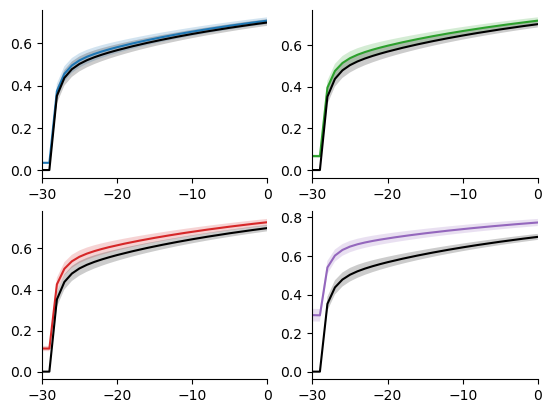

In [369]:
rot_colors = ['k', 'tab:blue', 'tab:green', 'tab:red', 'tab:purple']


plt.subplot(2,2,1)
for i, rot in enumerate(rot_num[1:]):
    plt.subplot(2,2,i+1)
    myplot(huberdeau_rot_outs[rot], color=rot_colors[i+1], label=f'rot {rot}') 
    myplot(huberdeau_rot_outs[0], color=rot_colors[0], label=f'rot 0')
    plt.xlim(-30, 0)
for i, rot in enumerate(rot_num):
    print(np.mean(huberdeau_rot_outs[rot][-29,:]-huberdeau_rot_outs[rot][-30,:]))    

In [370]:
delta_1st_step = [np.mean(huberdeau_rot_outs[rot][-29,:]-huberdeau_rot_outs[rot][-30,:]) for rot in rot_num]
# for i, rot in enumerate(rot_num):
#     print(np.mean(huberdeau_rot_outs[rot][-29,:]-huberdeau_rot_outs[rot][-30,:]))

<StemContainer object of 3 artists>

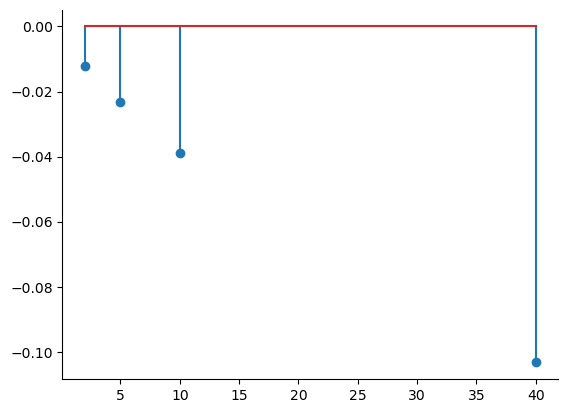

In [371]:
plt.stem(rot_num[1:], delta_1st_step[1:]-delta_1st_step[0])

([<matplotlib.axis.YTick at 0x7f2f1ea2ad60>,
 [Text(0, 0.0, '0.0000'),
  Text(0, 0.16666666666666666, '0.1667'),
  Text(0, 0.3333333333333333, '0.3333'),
  Text(0, 0.5, '0.5000'),
  Text(0, 0.6666666666666666, '0.6667'),
  Text(0, 0.8333333333333333, '0.8333')])

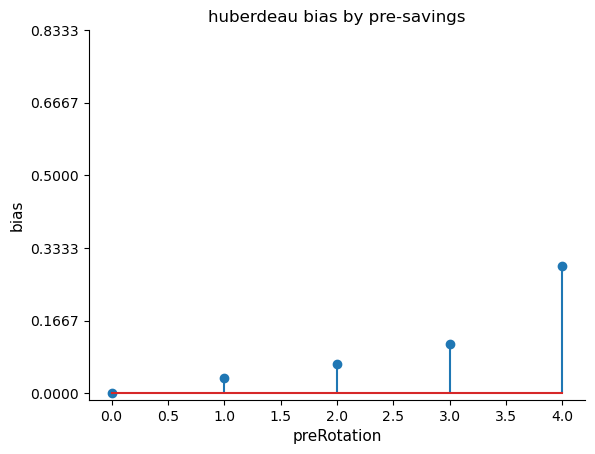

In [372]:
huberdeau_bias = [np.mean(huberdeau_rot_outs[rot][-30,:]) for i, rot in enumerate(rot_num)]
plt.stem( huberdeau_bias)
plt.xlabel('preRotation')
plt.ylabel('bias')
plt.title('huberdeau bias by pre-savings')
plt.yticks(np.arange(0,1,1/6))
    

(-30.0, 0.0)

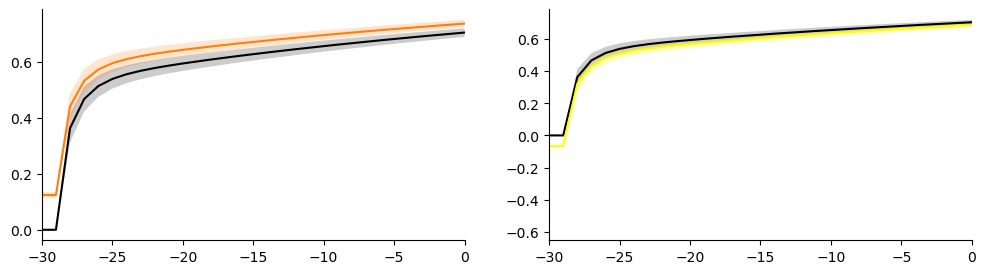

In [373]:
plt.figure(figsize=(12,3)
           )
plt.subplot(1,2,1)
myplot(huberdeau_rot_outs[0][:,:8],'k')
myplot(huberdeau_half_out[:,:8],'tab:orange')
plt.xlim(-30, 0)
plt.subplot(1,2,2)
myplot(huberdeau_rot_outs[0][:,:8],'k')
myplot(huberdeau_anti_out[:,:8],'yellow')
plt.xlim(-30, 0)

In [374]:
joiner_trial_num = [11,30,103,160]
eff_trials_min = 30 // 10
joiner_paradigms = {tt:np.array([0]*20+[1]*tt+[np.nan]*wait_time_equiv) for tt in joiner_trial_num}
joiner_paradigms['short_wait'] = np.array([0]*20+[1]*160+[np.inf]*3*eff_trials_min)
joiner_outs = {}
for tt in joiner_paradigms:
    joiner_outs[tt] = eval_single_wrap(model, joiner_paradigms[tt], args, paradigm_name=f'joiner_{tt}', record_internals=False, record_vectors=False)[0]



evaluating paradigm joiner_11 with 151 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm joiner_30 with 170 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm joiner_103 with 243 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm joiner_160 with 300 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm joiner_short_wait with 189 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


In [375]:
# joiner_outs = {k: joiner_outs[k][:,:8] for k in joiner_outs}

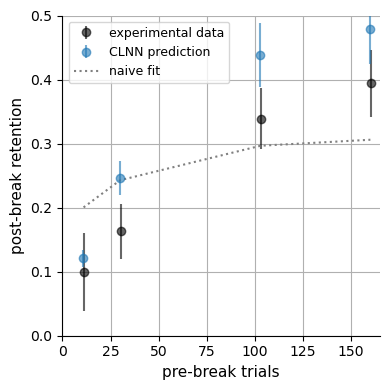

In [376]:
joiner_post_wait_outs = np.array([joiner_outs[tt][-1,:] for tt in joiner_trial_num])
joiner_pre_wait_outs = np.array([joiner_outs[tt][20+tt-1,:] for tt in joiner_trial_num])
#linear regression, with zero intercept of post wait bias on pre wait bias


plt.figure(figsize=(4,4))

experiment_mean_values = np.array([0.100, 0.163, 0.339, 0.394])
experiment_se = np.array([0.061, 0.043, 0.048, 0.052])


from sklearn.linear_model import LinearRegression
linreg = LinearRegression(fit_intercept=False)
linreg.fit(joiner_pre_wait_outs.mean(axis=1).reshape(-1, 1), experiment_mean_values.reshape(-1, 1))
slope = linreg.coef_[0][0]


h1 =plt.errorbar(0.3+np.array(joiner_trial_num), experiment_mean_values, yerr=experiment_se, fmt='o', color='black', alpha=0.6, label='experimental data')

h2 = plt.errorbar(-0.3+np.array(joiner_trial_num), np.mean(joiner_post_wait_outs, axis=1), yerr=np.std(joiner_post_wait_outs, axis=1)/np.sqrt(len(joiner_post_wait_outs[0])), 
             fmt='o', alpha=0.6, label='CLNN prediction',color='tab:blue')
h3 = plt.plot(joiner_trial_num, slope*np.mean(joiner_pre_wait_outs, axis=1),':', label='naive fit', color='gray')

# plt.plot([160], [np.mean(joiner_outs['short_wait'][-1,:])],'x')
# plt.errorbar([160], [np.mean(joiner_outs['short_wait'][-1,:])], yerr=np.std(joiner_outs['short_wait'][-1,:])/np.sqrt(len(joiner_outs['short_wait'][0])), fmt='o', color='red')
plt.xlabel('pre-break trials')
plt.ylabel('post-break retention')

plt.grid()

plt.xlim(0, 165)
plt.ylim(0, 0.5)
# plt.legend(['Experimental Data'])
plt.legend(handles=[h1, h2, h3[0]], labels=['experimental data', 'CLNN prediction', 'naive fit'], loc='upper left')
plt.tight_layout()

plt.show()


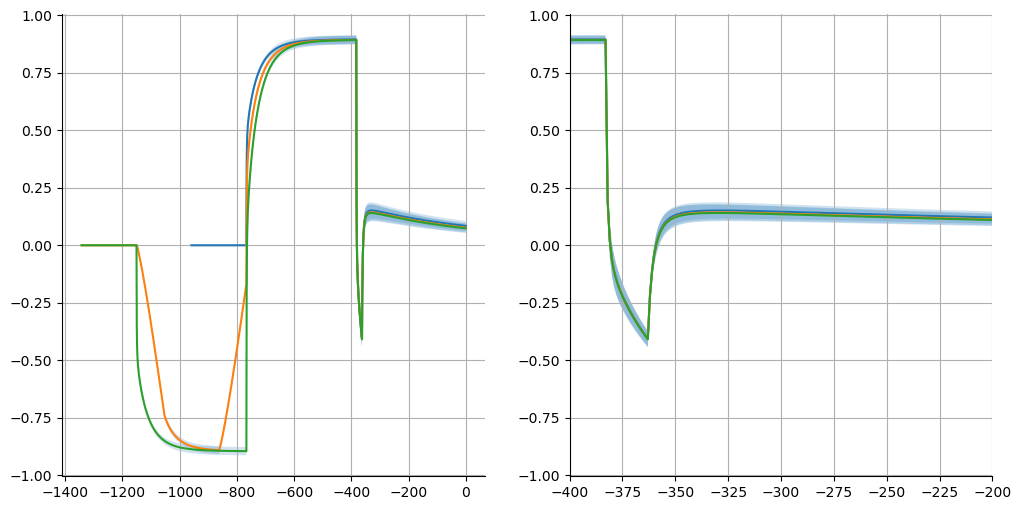

In [377]:

plt.figure(figsize=(12,6))
for ii in [1,2]:
    plt.subplot(1,2,ii)
    myplot(ooo['pretrained_sr_baseline'])
    myplot(ooo['pretrained_grad_sr'])
    myplot(ooo['pretrained_sr'])
    plt.grid()
    if ii==2:
        plt.xlim(-400,-200)

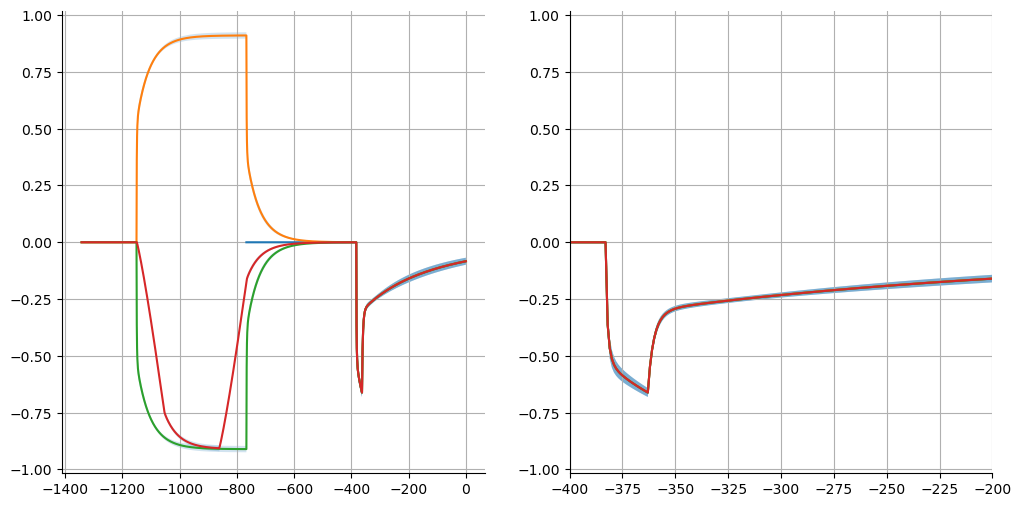

In [378]:
subjs = [0,8]
plt.figure(figsize=(12,6))
for ii in [1,2]:
    plt.subplot(1,2,ii)
    myplot(ooo['pekny_Nb'],subj=subjs)
    myplot(ooo['pekny_ANb'],subj=subjs)
    myplot(ooo['pekny_BNb'],subj=subjs)
    myplot(ooo['pekny_BgNb'],subj=subjs)
    plt.grid()
    if ii==2:
        plt.xlim(-400,-200)

In [379]:
import copy
args_ = copy.deepcopy(args)
args_.channel_trial_extra_error = 2.7/30.
args.noise_injection_node = 'u'
model_ = BatchedElboGenerativeModelTopMulti(device=device, args=args_,
                                           **({'fudge': args_.fudge} if hasattr(args_, 'fudge') else {})).to(device)
model_.get_biases_and_w_in(args_.n, device=device)
model_.load_state_dict(best_model_state_dict)

<All keys matched successfully>

In [380]:
# foo = eval_single_paradigm(model_, playlist['vaswFixedErr'], args, paradigm_name='vaswFixedErr', record_internals=False)
# foo = [foo_.detach().cpu().numpy() for foo_ in foo[0]]
# foo = np.array(foo)



foo, _ = eval_single_wrap(model_, playlist['vaswFixedErr'], args, paradigm_name='vaswFixedErr', record_internals=False)

evaluating paradigm vaswFixedErr with 300 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


(-1.5, 2.5)

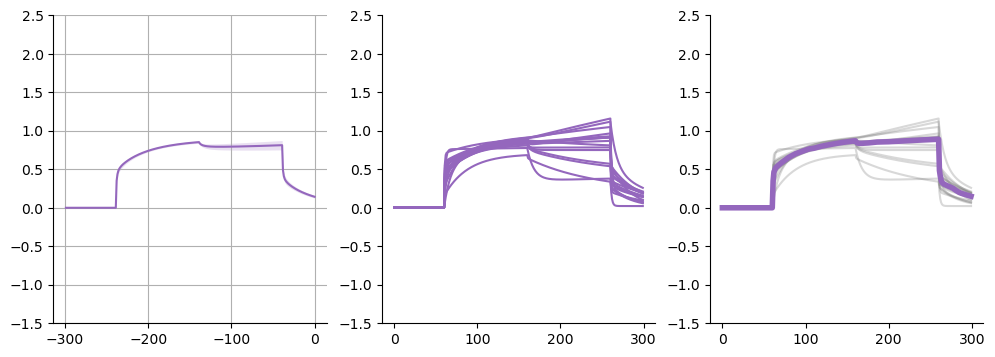

In [381]:
# foo = foo[:,8:]
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
myplot(foo, 'tab:purple')
plt.ylim(-1.5, 2.5)
plt.grid()
plt.subplot(1,3,2)
plt.plot(foo, 'tab:purple')
plt.ylim(-1.5, 2.5)
plt.subplot(1,3,3)
plt.plot(foo, 'tab:gray', alpha=0.3)
plt.plot(np.nanmedian(foo, axis=1), 'tab:purple', linewidth=4)

plt.ylim(-1.5, 2.5)


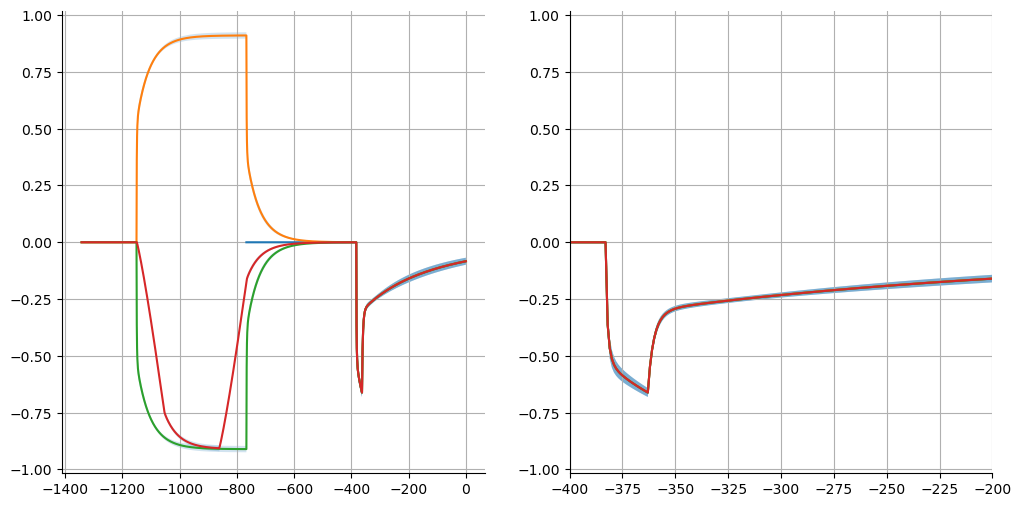

In [382]:
plt.figure(figsize=(12,6))
for ii in [1,2]:
    plt.subplot(1,2,ii)
    myplot(ooo['pekny_Nb'], subj=[0,8])
    myplot(ooo['pekny_ANb'], subj=[0,8])
    myplot(ooo['pekny_BNb'], subj=[0,8])
    myplot(ooo['pekny_BgNb'], subj=[0,8])
    plt.grid()
    if ii==2:
        plt.xlim(-400,-200)

In [383]:
wm_manipu_program = {'exp1': {'ref_paradigm':'wm_sr_baseline',    'noise_trial':596},
                     'exp2': {'ref_paradigm':'wmE2_sr_baseline',  'noise_trial':212},
                     'exp3': {'ref_paradigm':'wmE3_sr_baseline',  'noise_trial':576},
                     }

In [384]:
perturbed_results = {}
wait_results = {}

n_waits = 30// 10 *3
n_perturbs = n_waits *10

for exp in wm_manipu_program:
    ref_paradigm = wm_manipu_program[exp]['ref_paradigm']
    # at noise_trial, insert 30 trials with np.inf value to simulate working memory unroll
    noise_trial = wm_manipu_program[exp]['noise_trial']
    noise_seq = [np.inf]*n_perturbs
    wait_seq = [np.inf]*n_waits
    perturbed_paradigm = np.concatenate([playlist[ref_paradigm][:noise_trial], noise_seq, playlist[ref_paradigm][noise_trial:]])
    wait_paradigm = np.concatenate([playlist[ref_paradigm][:noise_trial], wait_seq, playlist[ref_paradigm][noise_trial:]])
    perturbed_out = eval_single_wrap(model, perturbed_paradigm, args, paradigm_name=f'{exp}_perturbed', record_internals=False, record_vectors=False)[0]
    wait_out = eval_single_wrap(model, wait_paradigm, args, paradigm_name=f'{exp}_wait', record_internals=False, record_vectors=False)[0]
    perturbed_results[exp] = (perturbed_out, noise_trial)
    wait_results[exp] = (wait_out, noise_trial)

evaluating paradigm exp1_perturbed with 878 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm exp1_wait with 797 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm exp2_perturbed with 452 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm exp2_wait with 371 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm exp3_perturbed with 858 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])
evaluating paradigm exp3_wait with 777 steps
noises shape: torch.Size([16]), ys shape: torch.Size([16])


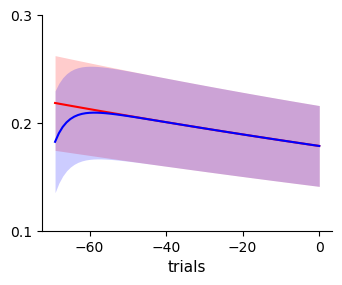

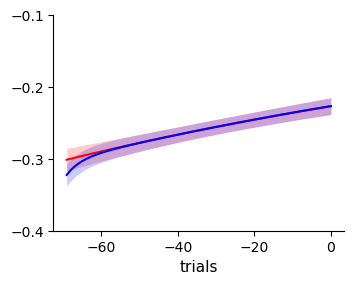

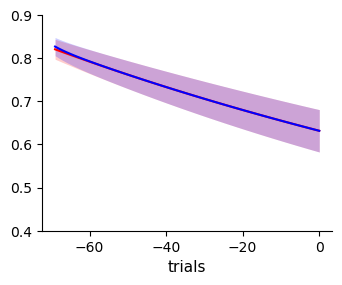

In [385]:
for exp in wm_manipu_program:
    if 'EXTENDED' in exp:
        continue
    plt.figure(figsize=(ufigx, ufigy))
    # myplot(ooo[wm_manipu_program[exp]['ref_paradigm']], label=exp)
    base_result = perturbed_results[exp][0]
    #remove the 30 noise trials from the perturbed result for plotting
    noise_trial = wm_manipu_program[exp]['noise_trial']
    base_result = np.concatenate([base_result[:noise_trial], base_result[noise_trial+n_perturbs:]])
    wait_result = np.concatenate([wait_results[exp][0][:noise_trial], wait_results[exp][0][noise_trial+n_waits:]])
    myplot(base_result[noise_trial:noise_trial+70][:,:8], label=f'{exp} perturbed', color='red')
    myplot(wait_result[noise_trial:noise_trial+70][:,:8], label=f'{exp} wait', color='blue')
    #ylim according to plotted data +-10%; yticks at every tenths within that range
    all_data = np.concatenate([np.mean(base_result[noise_trial:], axis=1), np.mean(wait_result[noise_trial:], axis=1)])
    data_min = np.min(all_data) 
    data_max = np.max(all_data)
    data_range = data_max - data_min
    # plt.ylim(data_min - 0.1*data_range, data_max + 0.1*data_range)
    plt.yticks(np.arange(np.floor(data_min*10)/10, np.ceil(data_max*10)/10 + 0.1, 0.1))
    plt.xlabel('trials')
    # plt.ylabel('adaptation')
    # plt.xlim(-200, -100)
    # plt.ylim(-1, 1)
# plt.legend()

In [386]:
# savepath = '/homes/ar2342/one_more_dir/contextual_frogs/gnu_fig_data/fitSRER_v1/fullRepertoires/eachSubj_v1'

# for k,v in ooo.items():
#     if 'herzfeld' in k or 'albert' in k:
#         continue
#     else:
#         print(f'saved paradigm {k} that has shape {v.shape}')
#         np.savetxt(f'{savepath}/{k}.txt', v)
